# HCRL Car Hacking Dataset — EDA for CAN Bus Intrusion Detection

**Datasets**: DoS, Fuzzy, RPM spoofing, Gear spoofing attacks on a Hyundai YF Sonata.

**Goal**: Characterize attack vs normal traffic patterns, identify trivial discriminators, and assess whether this dataset is suitable for training behavioral anomaly detectors.

## 1. Setup & Load

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('HCRL Car-Hacking')


In [2]:
def load_hcrl(path):
    rows = []
    with open(path) as f:
        reader = csv.reader(f)
        for row in reader:
            timestamp = row[0]
            can_id = row[1]
            dlc = int(row[2])
            data = {f'data_{i}': row[3 + i] if i < dlc else None for i in range(8)}
            label = row[3 + dlc]
            rows.append({
                'timestamp': timestamp,
                'can_id': can_id,
                'dlc': dlc,
                **data,
                'label': label,
            })

    df = pd.DataFrame(rows)
    df['timestamp'] = df['timestamp'].astype(float)
    df['dlc'] = df['dlc'].astype(int)
    df['is_attack'] = (df['label'] != 'R').astype(int)

    nan_labels = df['label'].isna().sum()
    assert nan_labels == 0, f"Corrupted/missing labels: {nan_labels} rows"

    return df

datasets = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    path = DATA_DIR / f"{name}_dataset.csv"
    df = load_hcrl(path)
    datasets[name] = df
    print(f"{name:>6s}: {df.shape[0]:>8,} rows, {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB, "
          f"missing cells: {df.isna().sum().sum()}")


   RPM: 4,621,702 rows, 2353.6 MB, missing cells: 248856
  gear: 4,443,142 rows, 2262.6 MB, missing cells: 240990


## 2. Class Balance

*Automotive relevance*: Attack ratio determines the baseline prevalence priors for an IDS. Heavily imbalanced sets (as here) mean a model must be evaluated on precision/recall, not accuracy.

In [3]:
def class_balance(df, name):
    counts = df['label'].value_counts()
    pct = df['label'].value_counts(normalize=True) * 100
    out = pd.DataFrame({'count': counts, 'percent': pct})
    print(f"\n=== {name} ===")
    print(out.to_string())
    return out

balance_data = {}
for name, df in datasets.items():
    balance_data[name] = class_balance(df, name)


=== DoS ===
         count    percent
label                    
R      3078250  83.972785
T       587521  16.027215

=== Fuzzy ===
         count    percent
label                    
R      3347013  87.187681
T       491847  12.812319

=== RPM ===
         count   percent
label                   
R      3966805  85.82996
T       654897  14.17004

=== gear ===
         count    percent
label                    
R      3845890  86.557891
T       597252  13.442109


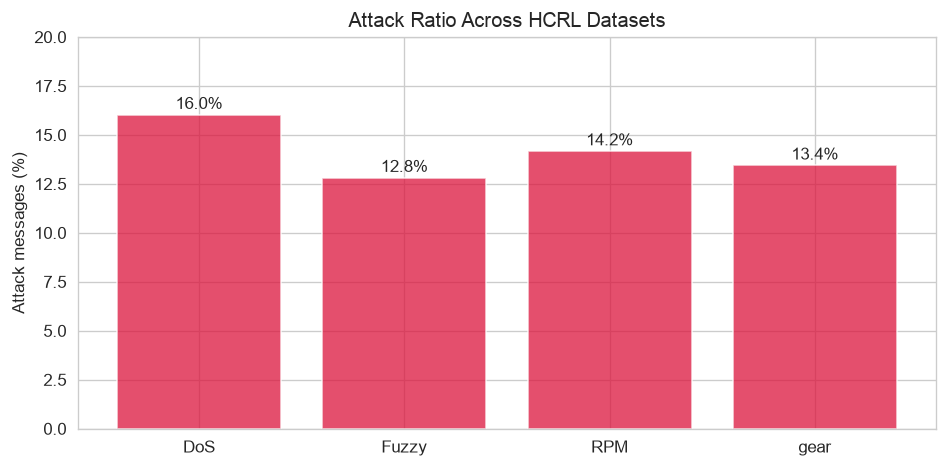

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(datasets.keys())
attack_pcts = [
    datasets[n]['is_attack'].mean() * 100 for n in labels
]
bars = ax.bar(labels, attack_pcts, color='crimson', alpha=0.75)
ax.set_ylabel('Attack messages (%)')
ax.set_title('Attack Ratio Across HCRL Datasets')
for bar, pct in zip(bars, attack_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', fontsize=10)
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()

## 3. CAN ID Analysis

*Automotive relevance*: Each CAN ID corresponds to a specific ECU function (e.g., 0x316 = RPM, 0x43F = gear). New or missing IDs are the most obvious attack signal. A robust IDS must also detect attacks that use legitimate IDs.

In [5]:
def can_id_analysis(df, name):
    mask_norm = df['label'] == 'R'
    mask_att = df['is_attack'] == 1

    norm_ids = set(df.loc[mask_norm, 'can_id'].unique())
    att_ids = set(df.loc[mask_att, 'can_id'].unique())
    new_ids = att_ids - norm_ids

    # Dominant attack ID
    att_id_counts = df.loc[mask_att, 'can_id'].value_counts()
    dom_id = att_id_counts.index[0] if len(att_id_counts) > 0 else None
    dom_pct = att_id_counts.iloc[0] / mask_att.sum() * 100 if dom_id else 0

    print(f"\n=== {name} ===")
    print(f"  Unique IDs (normal): {len(norm_ids)}")
    print(f"  Unique IDs (attack): {len(att_ids)}")
    print(f"  New IDs in attack only: {len(new_ids)}")
    print(f"  Dominant attack ID: 0x{dom_id} ({dom_pct:.1f}% of attack)")

    if dom_pct > 90:
        print(f"  *** FLAG: single ID 0x{dom_id} dominates {dom_pct:.1f}% of attack traffic ***")

    return {
        'name': name,
        'norm_ids': len(norm_ids),
        'att_ids': len(att_ids),
        'new_ids': len(new_ids),
        'dom_id': dom_id,
        'dom_pct': dom_pct,
    }

id_results = []
for name, df in datasets.items():
    id_results.append(can_id_analysis(df, name))


=== DoS ===
  Unique IDs (normal): 26
  Unique IDs (attack): 1
  New IDs in attack only: 1
  Dominant attack ID: 0x0000 (100.0% of attack)
  *** FLAG: single ID 0x0000 dominates 100.0% of attack traffic ***

=== Fuzzy ===
  Unique IDs (normal): 38
  Unique IDs (attack): 2048
  New IDs in attack only: 2010
  Dominant attack ID: 0x0322 (0.1% of attack)

=== RPM ===
  Unique IDs (normal): 26
  Unique IDs (attack): 1
  New IDs in attack only: 0
  Dominant attack ID: 0x0316 (100.0% of attack)
  *** FLAG: single ID 0x0316 dominates 100.0% of attack traffic ***

=== gear ===
  Unique IDs (normal): 26
  Unique IDs (attack): 1
  New IDs in attack only: 0
  Dominant attack ID: 0x043f (100.0% of attack)
  *** FLAG: single ID 0x043f dominates 100.0% of attack traffic ***


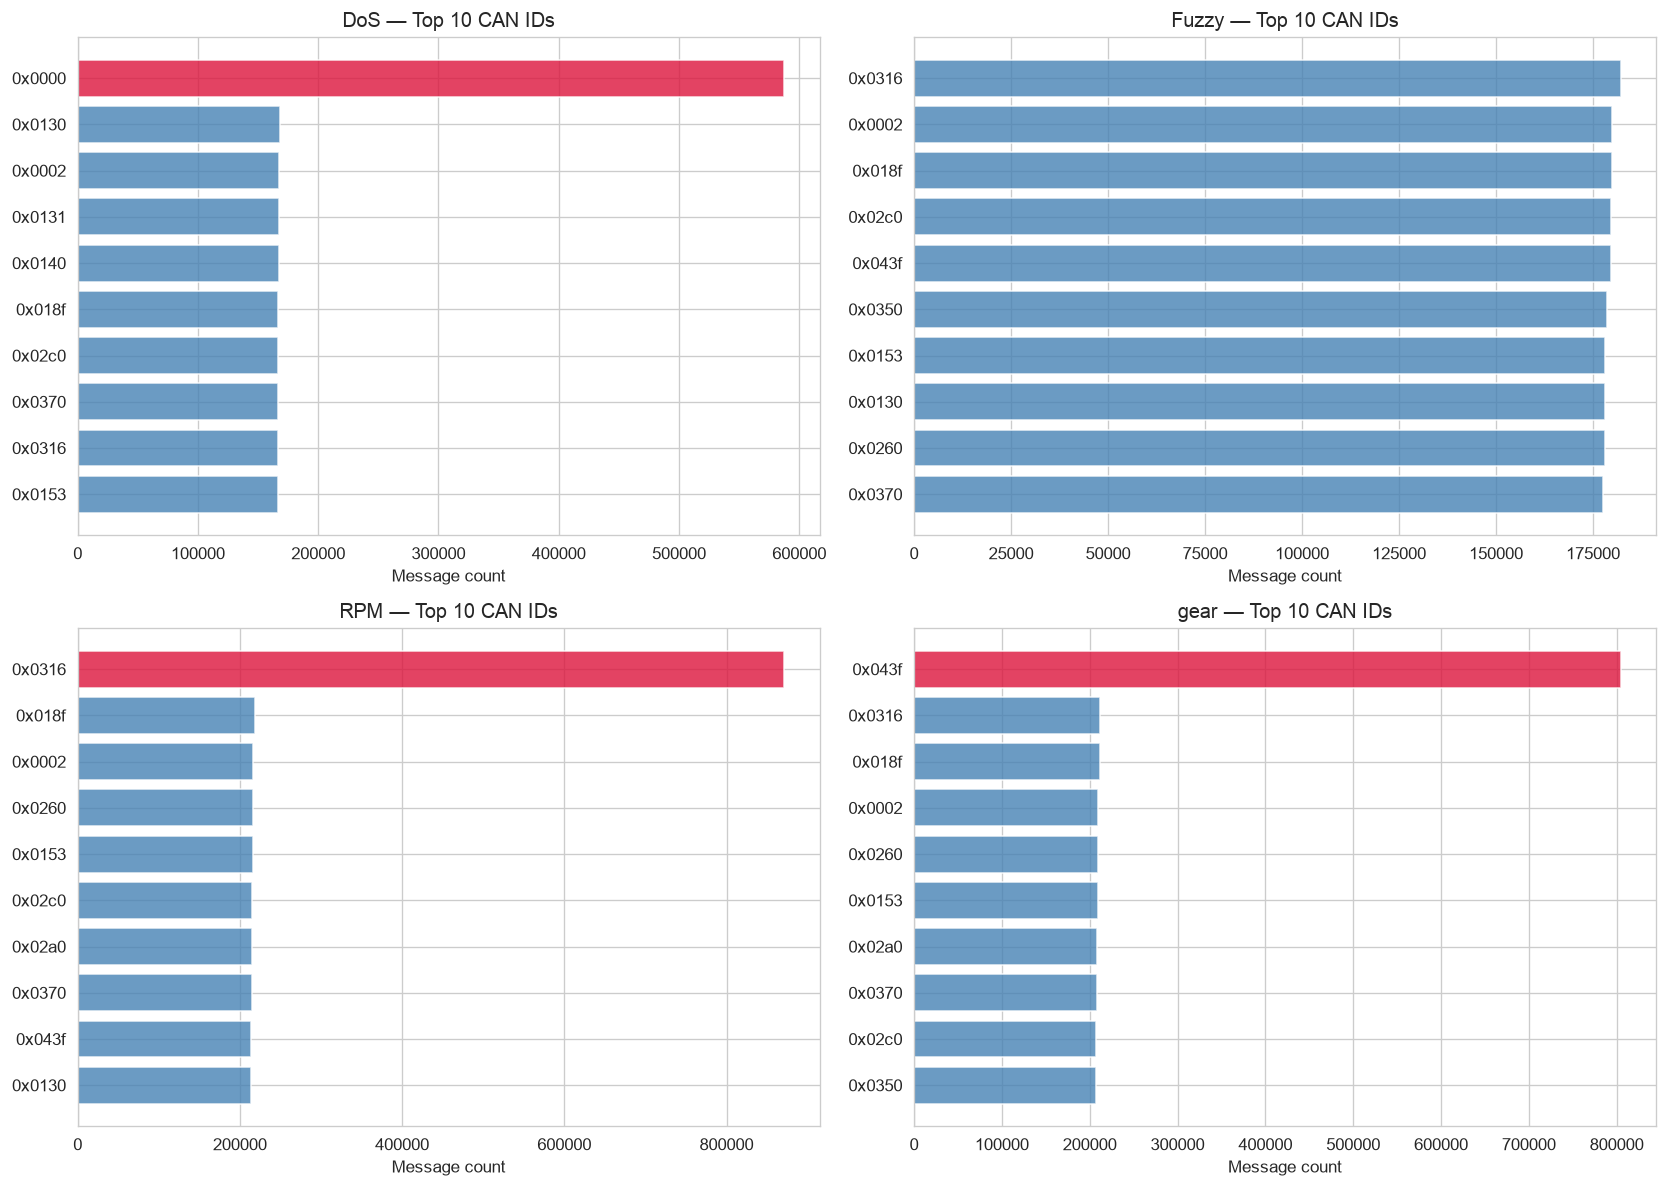

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, df) in zip(axes.flat, datasets.items()):
    # Top 10 CAN IDs by frequency
    top_ids = df['can_id'].value_counts().head(10)
    colors = ['crimson' if datasets[name].loc[
        datasets[name]['can_id'] == cid, 'is_attack'
    ].mean() > 0.5 else 'steelblue' for cid in top_ids.index]
    ax.barh([f'0x{cid}' for cid in top_ids.index], top_ids.values, color=colors, alpha=0.8)
    ax.set_title(f'{name} — Top 10 CAN IDs')
    ax.set_xlabel('Message count')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Red = attack-dominated, Blue = normal-dominated

## 4. Payload (DATA Bytes) Analysis

*Automotive relevance*: Payload bytes carry ECU signals. For RPM (0x316), bytes 2-3 encode the engine speed. An attack that continuously writes a constant value to these bytes while the engine is running is physiologically impossible — this is a powerful behavioral signal.

In [7]:
def payload_byte_variance(df, name, attack_id, byte_positions=range(8)):
    sub = df[df['can_id'] == attack_id].copy()
    if len(sub) == 0:
        print(f"  ID 0x{attack_id} not found in {name}")
        return

    print(f"\n--- {name}: ID 0x{attack_id} byte analysis ---")
    for b in byte_positions:
        col = f'data_{b}'
        norm_vals = sub.loc[sub['label'] == 'R', col]
        att_vals = sub.loc[sub['is_attack'] == 1, col]
        if len(norm_vals) == 0 or len(att_vals) == 0:
            continue
        norm_unique = norm_vals.nunique()
        att_unique = att_vals.nunique()
        norm_top5 = norm_vals.value_counts().head(5).to_dict()
        att_top5 = att_vals.value_counts().head(5).to_dict()
        print(f"  Byte {b}: norm_unique={norm_unique}, att_unique={att_unique}", end='')
        if att_unique == 1:
            const_val = att_vals.iloc[0]
            print(f"  *** FLAG: attack writes constant 0x{const_val} ***")
        else:
            print()
        if norm_unique <= 10:
            print(f"    Norm top-5: {norm_top5}")

for name, df in datasets.items():
    mask_att = df['is_attack'] == 1
    if mask_att.sum() == 0:
        continue
    top_att_id = df.loc[mask_att, 'can_id'].value_counts().index[0]
    payload_byte_variance(df, name, top_att_id)


--- DoS: ID 0x0000 byte analysis ---

--- Fuzzy: ID 0x0322 byte analysis ---

--- RPM: ID 0x0316 byte analysis ---
  Byte 0: norm_unique=1, att_unique=1  *** FLAG: attack writes constant 0x45 ***
    Norm top-5: {'05': 216334}
  Byte 1: norm_unique=8, att_unique=1  *** FLAG: attack writes constant 0x29 ***
    Norm top-5: {'21': 101132, '22': 83485, '23': 26876, '20': 3458, '25': 675}
  Byte 2: norm_unique=64, att_unique=1  *** FLAG: attack writes constant 0x24 ***
  Byte 3: norm_unique=2, att_unique=1  *** FLAG: attack writes constant 0xff ***
    Norm top-5: {'09': 162603, '0a': 53731}
  Byte 4: norm_unique=8, att_unique=1  *** FLAG: attack writes constant 0x29 ***
    Norm top-5: {'21': 101132, '22': 83485, '23': 26876, '20': 3458, '25': 675}
  Byte 5: norm_unique=6, att_unique=1  *** FLAG: attack writes constant 0x24 ***
    Norm top-5: {'20': 80806, '21': 65613, '1e': 40050, '22': 12116, '1d': 9930}
  Byte 6: norm_unique=1, att_unique=1  *** FLAG: attack writes constant 0x00 ***


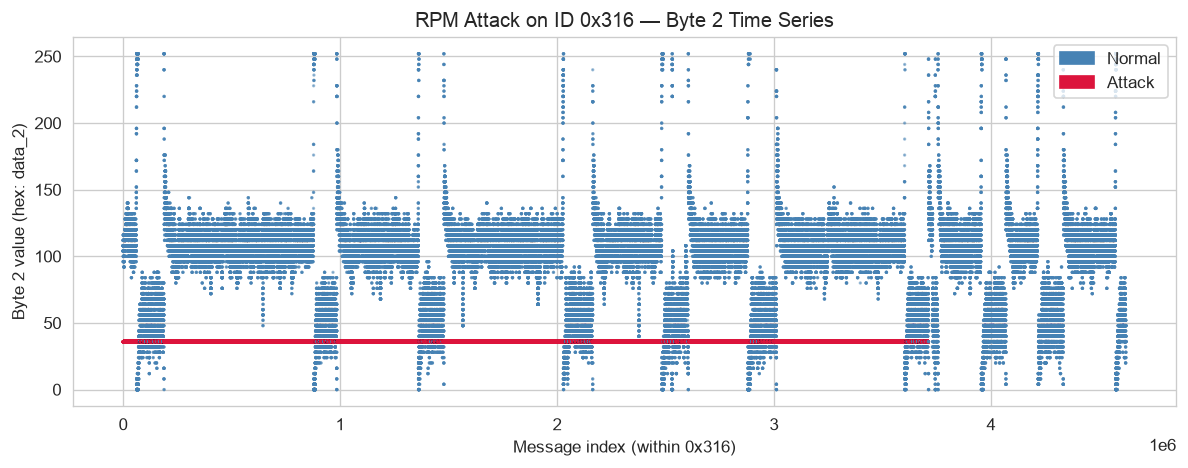

Normal byte2 unique values: 64
Attack byte2 unique values: 1
Attack constant value: 0x24


In [8]:
# RPM spoofing deep dive: visualize byte 2 (RPM hi-byte) on ID 0x316
rpm = datasets['RPM']
sub = rpm[rpm['can_id'] == '0316'].copy()
sub['byte2_int'] = sub['data_2'].apply(lambda x: int(x, 16))

fig, ax = plt.subplots(figsize=(10, 4))
colors = sub['label'].map({'R': 'steelblue', 'T': 'crimson'})
ax.scatter(sub.index, sub['byte2_int'], c=colors, s=1, alpha=0.5)
ax.set_xlabel('Message index (within 0x316)')
ax.set_ylabel('Byte 2 value (hex: data_2)')
ax.set_title('RPM Attack on ID 0x316 — Byte 2 Time Series')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='Normal'),
    Patch(color='crimson', label='Attack'),
])
plt.tight_layout()
plt.show()
print(f"Normal byte2 unique values: {sub.loc[sub['label']=='R', 'data_2'].nunique()}")
print(f"Attack byte2 unique values: {sub.loc[sub['label']!='R', 'data_2'].nunique()}")
print(f"Attack constant value: 0x{sub.loc[sub['label']!='R', 'data_2'].iloc[0]}")

## 5. DLC Analysis

*Automotive relevance*: Most powertrain ECUs use fixed DLC=8. Shorter DLC (2, 5, 6) appears when the sender signals fewer valid bytes — a common pattern in diagnostic/tool messages. A fuzzy attack that randomly varies DLC can be detected by DLC sanity checks against a known-ID-to-DLC mapping.

In [9]:
def dlc_analysis(df, name):
    print(f"\n=== {name} ===")
    dlc_norm = df.loc[df['label'] == 'R', 'dlc'].value_counts().sort_index()
    dlc_att = df.loc[df['is_attack'] == 1, 'dlc'].value_counts().sort_index()
    print("  DLC | Normal    Attack")
    all_dlc = sorted(set(dlc_norm.index) | set(dlc_att.index))
    for d in all_dlc:
        n = dlc_norm.get(d, 0)
        a = dlc_att.get(d, 0)
        flag = "  *** UNUSUAL ***" if d not in (8,) else ""
        print(f"  {d:>3d} | {n:>8,}  {a:>8,}{flag}")

for name, df in datasets.items():
    dlc_analysis(df, name)


=== DoS ===
  DLC | Normal    Attack
    2 |   31,188         0  *** UNUSUAL ***
    8 | 3,047,062   587,521

=== Fuzzy ===
  DLC | Normal    Attack
    2 |   34,382         0  *** UNUSUAL ***
    5 |   53,451         0  *** UNUSUAL ***
    6 |        3         0  *** UNUSUAL ***
    8 | 3,259,177   491,847

=== RPM ===
  DLC | Normal    Attack
    2 |   41,476         0  *** UNUSUAL ***
    8 | 3,925,329   654,897

=== gear ===
  DLC | Normal    Attack
    2 |   40,165         0  *** UNUSUAL ***
    8 | 3,805,725   597,252


## 6. Inter-Arrival Time (IAT) Analysis

*Automotive relevance*: A CAN bus has finite bandwidth (~500 kbps). Attack injections can saturate the bus, compressing IAT. Conversely, a well-paced injection that matches normal cadence avoids IAT-based detection. The HCRL DoS attack is known to pace itself rather than flood — we verify this below.

In [10]:
def iat_analysis(df, name, sample_size=100000):
    """Compare IAT distribution between normal and attack intervals."""
    df_sorted = df.sort_values('timestamp').reset_index(drop=True)
    df_sorted['iat'] = df_sorted['timestamp'].diff().fillna(0)

    norm_iat = df_sorted.loc[df_sorted['label'] == 'R', 'iat']
    att_iat = df_sorted.loc[df_sorted['is_attack'] == 1, 'iat']

    # Sample if too large
    if len(norm_iat) > sample_size:
        norm_iat = norm_iat.sample(sample_size, random_state=0)
    if len(att_iat) > sample_size:
        att_iat = att_iat.sample(sample_size, random_state=0)

    print(f"\n=== {name} IAT (seconds) ===")
    for label_, series in [('Normal', norm_iat), ('Attack', att_iat)]:
        print(f"  {label_:>6s}: mean={series.mean():.6f}  median={series.median():.6f}  "
              f"std={series.std():.6f}  min={series.min():.6f}  max={series.max():.6f}")

    # Determine if attack causes compression
    att_median = att_iat.median()
    norm_median = norm_iat.median()
    ratio = att_median / norm_median if norm_median > 0 else float('inf')
    if ratio < 0.8:
        print(f"  *** FLAG: attack IAT is {ratio:.2f}x normal (compression/bus flooding) ***")
    elif ratio > 1.2:
        print(f"  *** FLAG: attack IAT is {ratio:.2f}x normal (slower cadence) ***")
    else:
        print(f"  Attack IAT blends in with normal cadence (ratio={ratio:.2f})")

    return norm_iat, att_iat

iat_results = {}
for name, df in datasets.items():
    iat_results[name] = iat_analysis(df, name)


=== DoS IAT (seconds) ===
  Normal: mean=0.000644  median=0.000244  std=0.001155  min=0.000109  max=0.016557
  Attack: mean=0.001367  median=0.000247  std=0.002274  min=0.000131  max=0.042386
  Attack IAT blends in with normal cadence (ratio=1.01)

=== Fuzzy IAT (seconds) ===
  Normal: mean=0.000655  median=0.000243  std=0.001161  min=0.000028  max=0.015852
  Attack: mean=0.001528  median=0.000407  std=0.002182  min=0.000160  max=0.021019
  *** FLAG: attack IAT is 1.68x normal (slower cadence) ***

=== RPM IAT (seconds) ===
  Normal: mean=0.000495  median=0.000243  std=0.000776  min=0.000106  max=0.016519
  Attack: mean=0.000725  median=0.000316  std=0.001001  min=0.000170  max=0.011760
  *** FLAG: attack IAT is 1.30x normal (slower cadence) ***

=== gear IAT (seconds) ===
  Normal: mean=0.000512  median=0.000243  std=0.000817  min=0.000114  max=0.012700
  Attack: mean=0.000802  median=0.000331  std=0.001163  min=0.000015  max=0.018929
  *** FLAG: attack IAT is 1.36x normal (slower ca

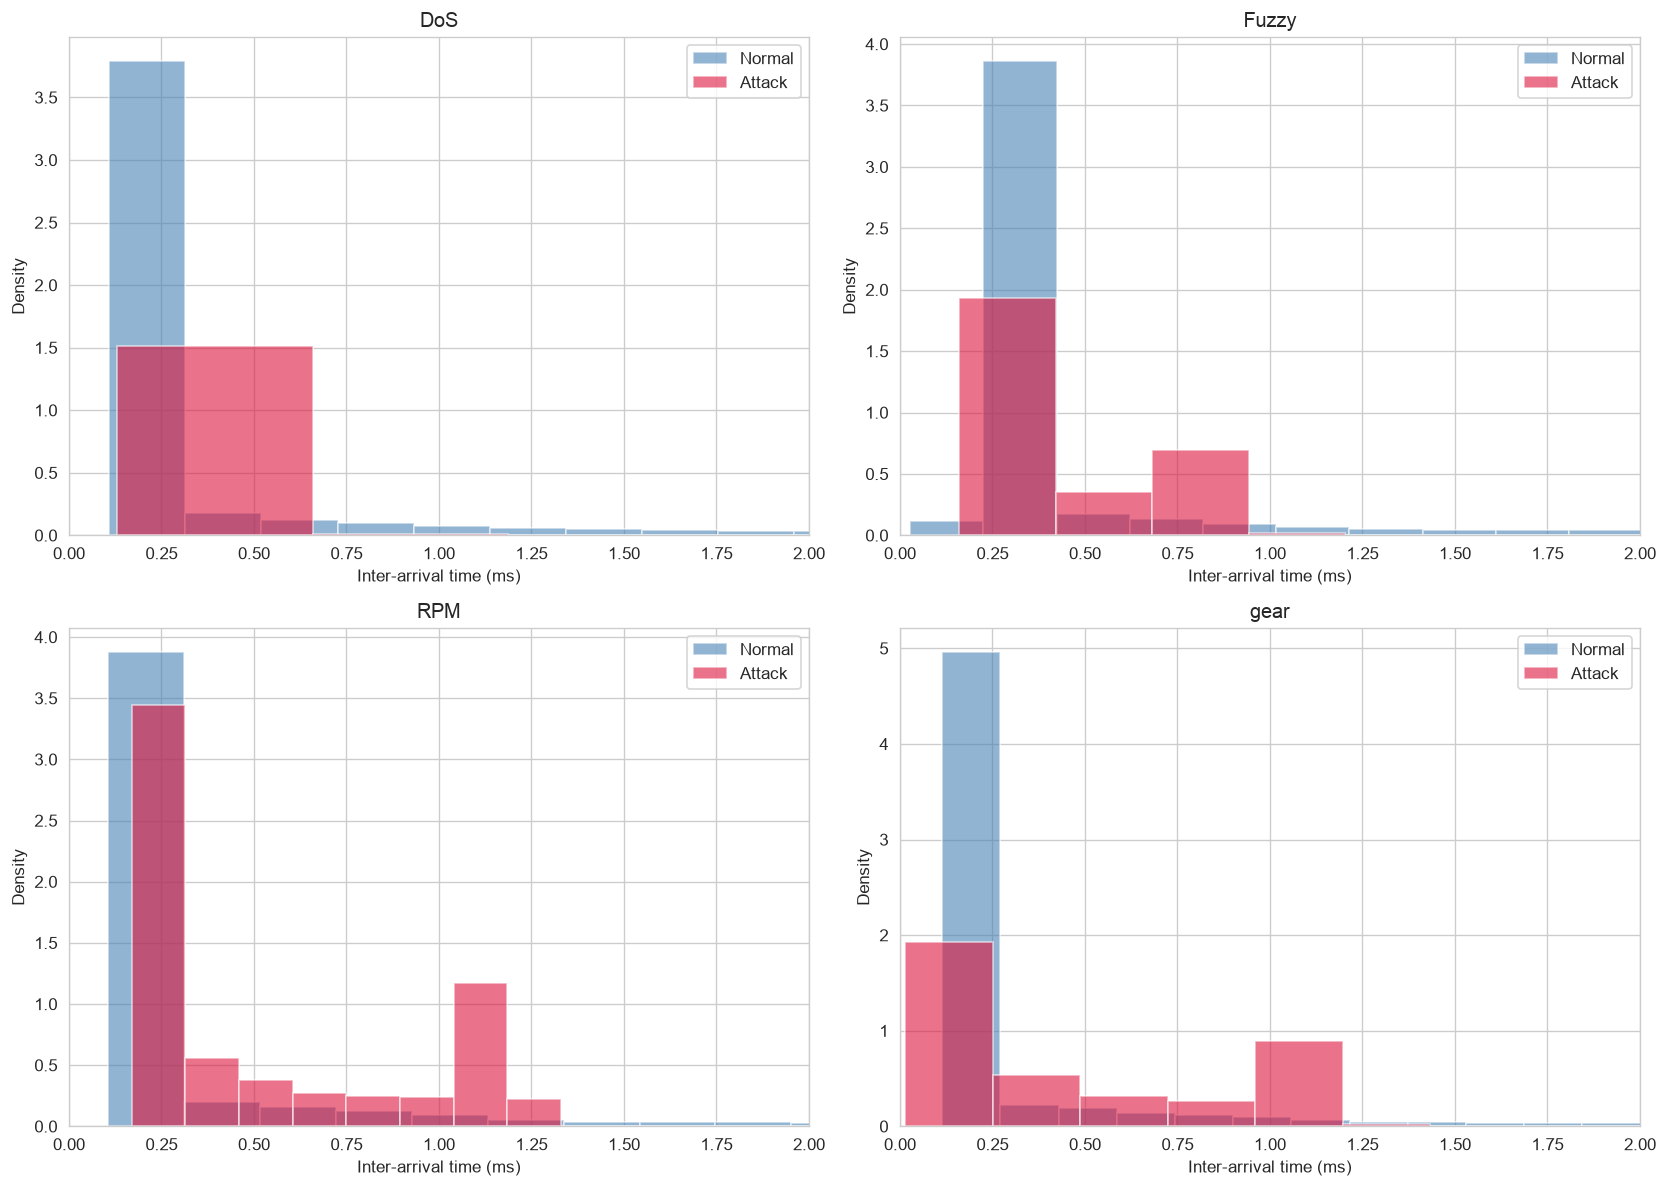

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, (norm_iat, att_iat)) in zip(axes.flat, iat_results.items()):
    ax.hist(norm_iat * 1000, bins=80, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(att_iat * 1000, bins=80, alpha=0.6, label='Attack', color='crimson', density=True)
    ax.set_xlim(0, 2)  # focus on typical < 2ms window
    ax.set_xlabel('Inter-arrival time (ms)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}')
    ax.legend()
plt.tight_layout()
plt.show()

## 7. "Trivial Rule" Baseline Check

*Why this matters*: If a one-line rule ("if CAN ID not in safe-set → attack") achieves F1 > 0.99, the dataset is **presence-based** and any ML model that achieves comparable F1 has not learned anything useful about *behavioral* anomalies. Real attacks (e.g., rogue CAN signal within a legitimate ID) require behavioral models.

We define three naive detectors:
- **Rule A**: Message with CAN ID **never seen in normal** traffic → attack (catches new-ID injection like Fuzzy)
- **Rule B**: Message from a **dominant attack ID** (single ID >90% of attack) → attack (catches DoS, RPM, Gear)
- **Rule C**: Messages on the dominant attack ID with **constant byte value** → attack (catches RPM constant-payload)

In [12]:
from sklearn.metrics import precision_recall_fscore_support

def evaluate_rule(y_true, y_pred, rule_name):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    return {'rule': rule_name, 'precision': p, 'recall': r, 'f1': f1}

def trivial_rules_check(df, name):
    y_true = df['is_attack'].values
    results = []

    # Rule A: unseen IDs -> attack
    normal_ids = set(df.loc[df['label'] == 'R', 'can_id'].unique())
    pred_a = (~df['can_id'].isin(normal_ids)).astype(int).values
    results.append(evaluate_rule(y_true, pred_a, 'Rule A: new ID'))

    # Rule B: dominant attack ID -> attack
    mask_att = df['is_attack'] == 1
    if mask_att.sum() > 0:
        top_att_id = df.loc[mask_att, 'can_id'].value_counts().index[0]
        top_pct = df.loc[mask_att, 'can_id'].value_counts().iloc[0] / mask_att.sum()
        if top_pct > 0.9:
            pred_b = (df['can_id'] == top_att_id).astype(int).values
            results.append(evaluate_rule(y_true, pred_b, 'Rule B: dominant ID'))

    # Rule C: constant byte on dominant attack ID -> attack
    if mask_att.sum() > 0:
        top_id = df.loc[mask_att, 'can_id'].value_counts().index[0]
        sub = df[df['can_id'] == top_id]
        for b in range(8):
            col = f'data_{b}'
            att_vals = sub.loc[mask_att & (df['can_id'] == top_id), col]
            if att_vals.nunique() == 1:
                const_val = att_vals.iloc[0]
                pred_c = ((df['can_id'] == top_id) & (df[col] == const_val)).astype(int).values
                results.append(evaluate_rule(y_true, pred_c, f'Rule C: constant 0x{col}={const_val}'))

    print(f"\n=== {name} — Naive Rule Evaluation ===")
    best = max(results, key=lambda r: r['f1'])
    for r in results:
        flag = " ** BEST **" if r['f1'] >= best['f1'] else ""
        print(f"  {r['rule']:>30s}: P={r['precision']:.4f}  R={r['recall']:.4f}  F1={r['f1']:.4f}{flag}")

    is_trivial = best['f1'] > 0.99
    if is_trivial:
        print(f"  *** WARNING: best naive F1={best['f1']:.4f} — this dataset is PRESENCE-BASED ***")
        print(f"  *** ML models may appear to perform near-perfectly while learning nothing behavioral ***")
    return best

trivial_results = {}
for name, df in datasets.items():
    trivial_results[name] = trivial_rules_check(df, name)


=== DoS — Naive Rule Evaluation ===
                  Rule A: new ID: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
             Rule B: dominant ID: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_0=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_1=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_2=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_3=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_4=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_5=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_6=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
    Rule C: constant 0xdata_7=00: P=1.0000  R=1.0000  F1=1.0000 ** BEST **
  *** WARNING: best naive F1=1.0000 — this dataset is PRESENCE-BASED ***
  *** ML models may appear to perform near-perfectly while learning nothing behavioral ***

=== Fuzzy — Naive Rule Evaluation ===
          

## 8. Summary Table

,Attack %,Dominant Attack ID,Key Discriminator,Naive Rule F1,Trivially Separable
Dataset,,,,,
DoS,16.0%,0x0000,ID 0x0000 (100% of attack),1.0000,YES
Fuzzy,12.8%,0x0322,2010 new IDs injected,0.9904,YES
RPM,14.2%,0x0316,ID 0x0316 (100% of attack),1.0000,YES
gear,13.4%,0x043f,ID 0x043f (100% of attack),1.0000,YES


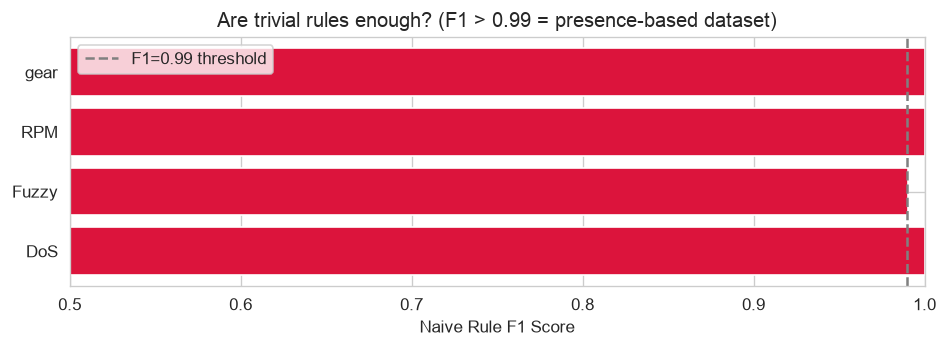

In [13]:
rows = []
for name, df in datasets.items():
    mask_att = df['is_attack'] == 1
    attack_pct = mask_att.mean() * 100
    top_att_id = df.loc[mask_att, 'can_id'].value_counts().index[0] if mask_att.sum() > 0 else '-'
    top_pct = df.loc[mask_att, 'can_id'].value_counts().iloc[0] / mask_att.sum() * 100 if mask_att.sum() > 0 else 0
    normal_ids = set(df.loc[df['label'] == 'R', 'can_id'].unique())
    new_ids = set(df.loc[mask_att, 'can_id'].unique()) - normal_ids

    # Describe discriminating feature
    if len(new_ids) > 100:
        disc_feat = f"{len(new_ids)} new IDs injected"
    else:
        disc_feat = f"ID 0x{top_att_id} ({top_pct:.0f}% of attack)"

    best = trivial_results[name]
    rows.append({
        'Dataset': name,
        'Attack %': f'{attack_pct:.1f}%',
        'Dominant Attack ID': f'0x{top_att_id}',
        'Key Discriminator': disc_feat,
        'Naive Rule F1': f'{best["f1"]:.4f}',
        'Trivially Separable': 'YES' if best['f1'] > 0.99 else 'no',
    })

summary = pd.DataFrame(rows).set_index('Dataset')
display(summary)

# Visual summary
fig, ax = plt.subplots(figsize=(8, 3))
colors_sum = ['crimson' if r['f1'] > 0.99 else 'orange' for r in trivial_results.values()]
ax.barh(list(trivial_results.keys()), [r['f1'] for r in trivial_results.values()], color=colors_sum)
ax.axvline(0.99, color='gray', ls='--', label='F1=0.99 threshold')
ax.set_xlabel('Naive Rule F1 Score')
ax.set_title('Are trivial rules enough? (F1 > 0.99 = presence-based dataset)')
ax.legend()
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

## Dataset Limitations for Intrusion Detection Evaluation

### What HCRL does well
- Provides a clean, labeled benchmark for CAN IDS research
- Covers 4 attack types with realistic bus timing from a production vehicle (Hyundai YF Sonata)
- Large enough (>3M messages per class) to train data-hungry models like LSTMs

### Critical limitations

1. **Presence-based attacks**: Every attack in this dataset can be detected with near-100% F1 by checking whether a CAN ID is novel or whether a constant byte appears on a known ID. No attack uses a legitimate ID with a plausible-but-malicious payload.

2. **Single vehicle, single day**: All data comes from one Hyundai YF Sonata on one test run. CAN ID mappings, timing, and payload formats vary between manufacturers, models, and even ECU firmware versions.

3. **No stealth attacks**: Real-world attackers (per ISO 21434 threat analysis) aim to blend in — they spoof the correct CAN ID, match the correct DLC, and send plausible signal values. HCRL contains none of this.

4. **No mixed-attack scenarios**: Each file contains one attack type vs normal. Real buses may experience multi-stage attacks (e.g., reconnaissance via diagnostic messages, then spoofing a powertrain signal).

5. **IAT not compressed**: The DoS attack paces itself at normal bus cadence, meaning IAT-based detection doesn't trigger. While this is "stealthy," it also means the dataset does not test a bus-flood scenario.

### Recommended complementary benchmarks
- **ROAD (Real ORNL Automotive Dy framework)**: Attacks injected over legitimate IDs with realistic payload manipulation. Harder behavioral benchmark.
- **can-train-and-test**: Open-source CAN attack framework that generates synthetic attacks with controllable stealth level.
- **Survival analysis / time-to-detection**: Also consider evaluating how *quickly* each attack is detected, not just overall F1.